In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv('./data/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1
...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830,0
1334,18,0,31.920,0,0,0,2205.98080,1
1335,18,0,36.850,0,0,2,1629.83350,1
1336,21,0,25.800,0,0,3,2007.94500,0


<AxesSubplot:>

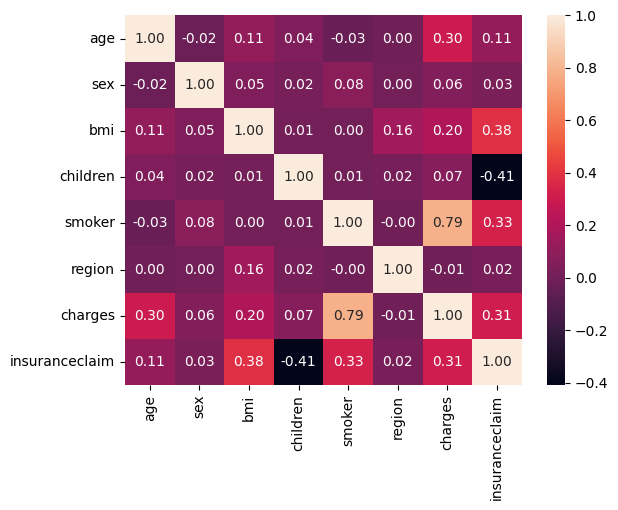

In [3]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

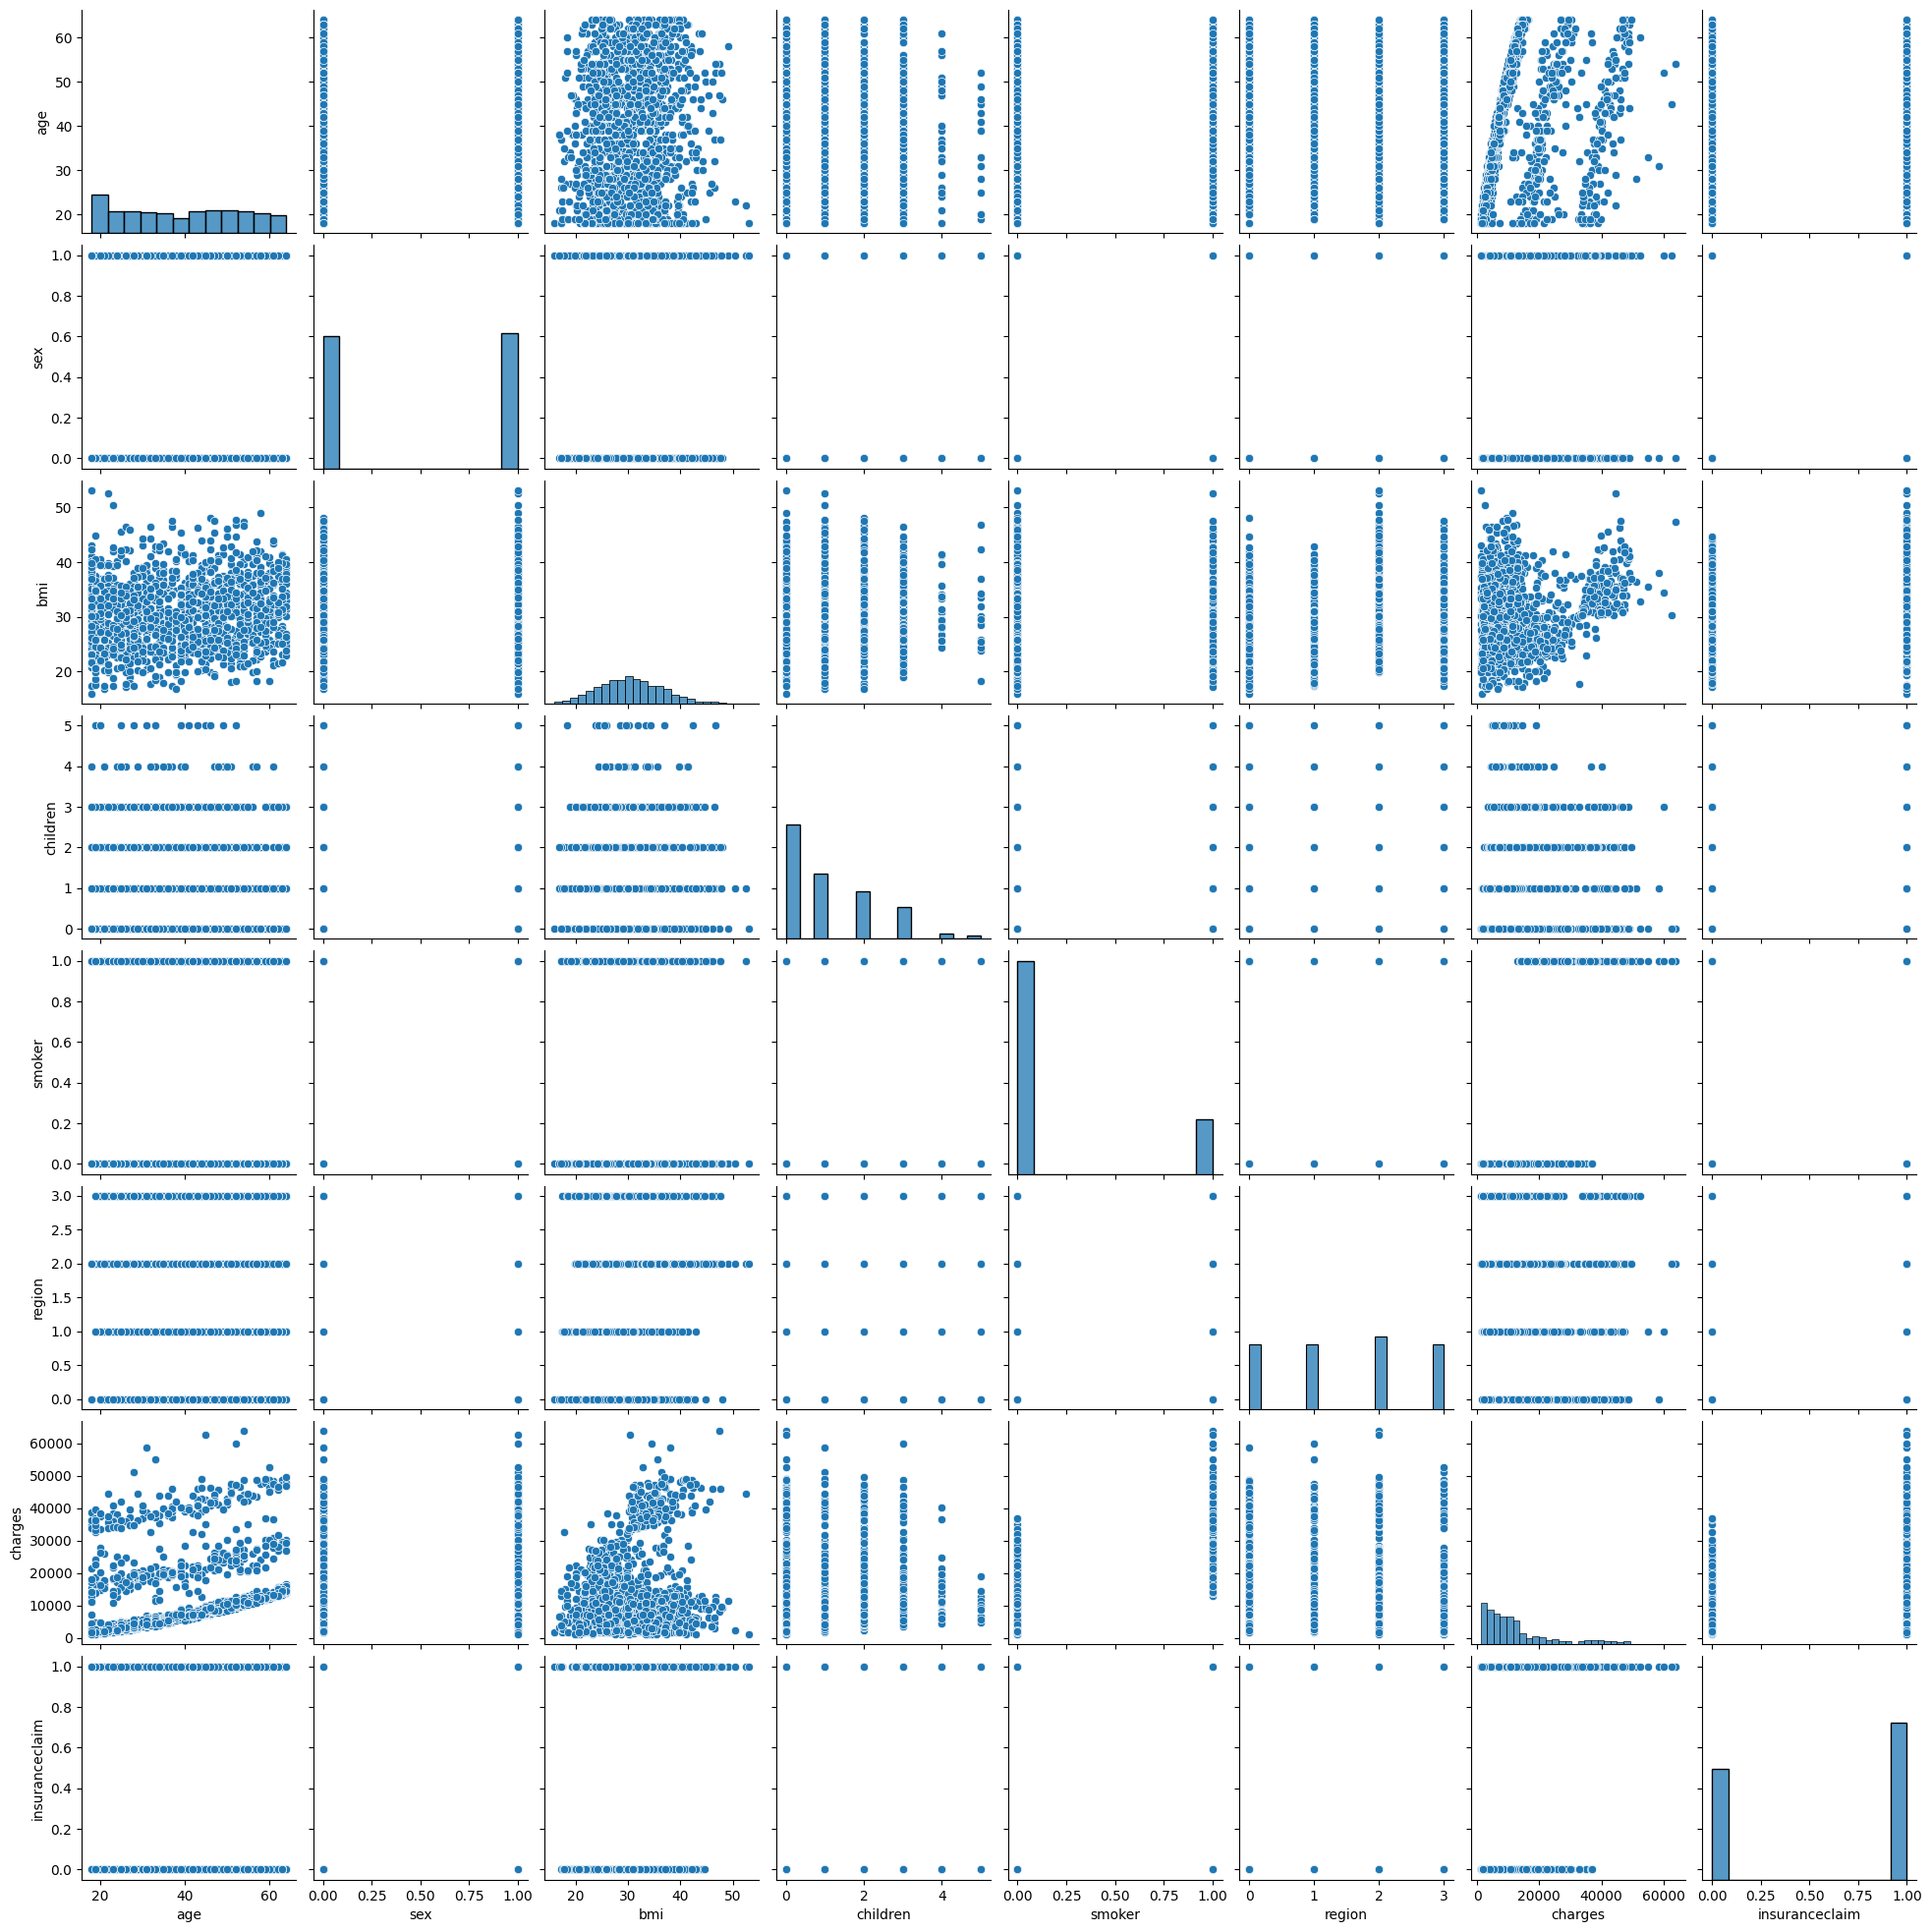

In [4]:
sns.pairplot(df)

# Linear Regression

In [5]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_feature = 'age'
y_feature = 'charges'

x = x_scaler.fit_transform(df[[x_feature]])
y = y_scaler.fit_transform(df[[y_feature]])

(x_train, x_test, y_train, y_test) = train_test_split(x, y, test_size=0.1, random_state=42)

In [6]:
linreg_model = LinearRegression()
linreg_model.fit(x_train, y_train)
linreg_model

LinearRegression()

In [7]:
y_pred = linreg_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

x_test_original = x_scaler.inverse_transform(x_test)
y_pred_original = y_scaler.inverse_transform(y_pred)

print(f"Model Intercept: {linreg_model.intercept_[0]:.5f}")
print(f"Model Coefficient (Slope): {linreg_model.coef_[0][0]:.5f}")
print(f"Mean Squared Error (MSE) on Test Data: {mse:.2f}")
print(f"R-squared (R²) Score on Test Data: {r2:.2f}")

Model Intercept: 0.00419
Model Coefficient (Slope): 0.29280
Mean Squared Error (MSE) on Test Data: 0.82
R-squared (R²) Score on Test Data: 0.12


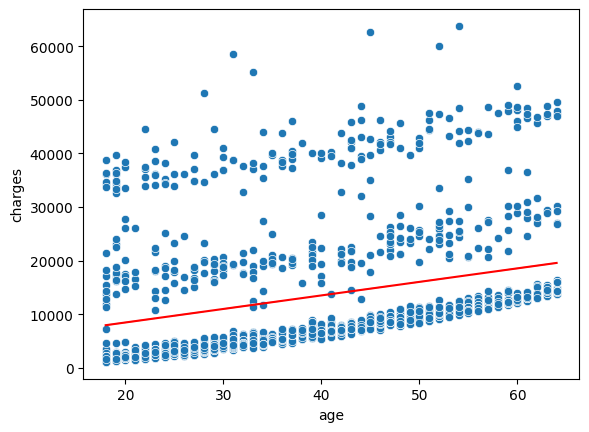

In [8]:
sns.scatterplot(df, x=x_feature, y=y_feature)
sns.lineplot(pd.DataFrame({x_feature: x_test_original.flatten(), y_feature: y_pred_original.flatten()}), x=x_feature, y=y_feature, color='red')
plt.show()

# Logistic Regression

In [9]:
x_scaler = StandardScaler()

X = x_scaler.fit_transform(df[['children']])
y = df['insuranceclaim']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [10]:
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)
logreg_model

LogisticRegression()

In [11]:
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

pd.DataFrame({f'x (children)': x_scaler.inverse_transform(X_test).flatten(), 'y_true': y_test, 'y_pred': y_pred})

Accuracy:  0.75
Precision: 0.75
Recall:    0.81
F1 Score:  0.78


,x (children),y_true,y_pred
764,2.0,1,0
887,0.0,1,1
890,0.0,1,1
1293,3.0,1,0
259,0.0,1,1
...,...,...,...
358,0.0,1,1
551,0.0,1,1
778,3.0,0,0
1127,2.0,0,0


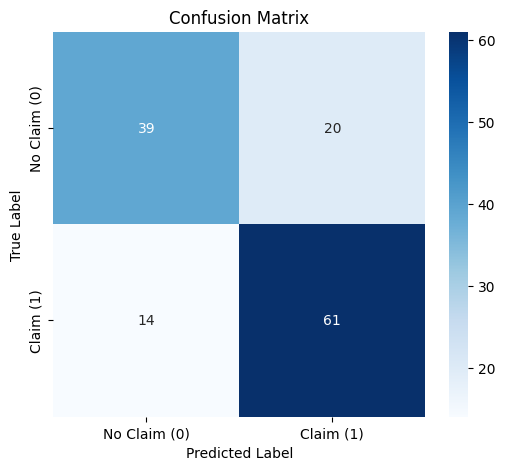

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Claim (0)', 'Claim (1)'],
            yticklabels=['No Claim (0)', 'Claim (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()